# CAV Weight Extraction — TNet with AIXI Concepts
Extracting and visualising the linear classifier weights (CAV vectors) from TCAV on TNet, using the AIXI geometric concepts (squares, circles, crosses) against random pools.

In [15]:
import sys, os
os.chdir("/Users/dylancanning/Documents/TFG/Tcav_Captum/Testing-with-Concept-Activation-Vectors")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset

from model.model_sq import TNet

print("Imports OK")
print(f"Working dir: {os.getcwd()}")

Imports OK
Working dir: /Users/dylancanning/Documents/TFG/Tcav_Captum/Testing-with-Concept-Activation-Vectors


In [16]:
# ==========================================
# 1. Load TNet model
# ==========================================
PESOS = "weights/only_sq.pt"
DEVICE = torch.device("cpu")

obj = torch.load(PESOS, map_location=DEVICE, weights_only=True)
in_channels = obj["conv1.weight"].shape[1]
num_classes  = obj["fc4.weight"].shape[0]

model = TNet(numChannels=in_channels, classes=num_classes, size_img=128)
model.to(DEVICE).eval()
model.load_state_dict(obj)

print(f"Loaded TNet(in_channels={in_channels}, classes={num_classes}) on {DEVICE}")
print(model)

Loaded TNet(in_channels=1, classes=1) on cpu
TNet(
  (conv1): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (bn1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(25, 35, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (bn2): BatchNorm2d(35, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(35, 50, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu3): ReLU()
  (bn3): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu4): ReLU()
  (bn4): Batch

In [17]:
# ==========================================
# 2. Setup transforms & concept loader
# ==========================================
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("L")
    return transform(img).to(DEVICE).float()

def assemble_concept(name, id, concepts_path="data/concepts"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

print("Concept loader ready")

Concept loader ready


In [18]:
# ==========================================
# 3. Assemble AIXI concepts
# ==========================================
concepts_path = "./data/concepts"

# Core shape concepts
circle_full = assemble_concept("circle_full", 0, concepts_path=concepts_path)
cross_full  = assemble_concept("cross_full",  1, concepts_path=concepts_path)
square_full = assemble_concept("square_full", 2, concepts_path=concepts_path)

# Random pools (control)
random_pool   = assemble_concept("random_pool",   100, concepts_path=concepts_path)
random_pool_2 = assemble_concept("random_pool_2", 101, concepts_path=concepts_path)
random_pool_3 = assemble_concept("random_pool_3", 102, concepts_path=concepts_path)
random_pool_4 = assemble_concept("random_pool_4", 103, concepts_path=concepts_path)

CONCEPTS = {
    "circle_full": circle_full,
    "cross_full":  cross_full,
    "square_full": square_full,
}

print(f"Concepts assembled: {list(CONCEPTS.keys())}")
print(f"Random pools: random_pool, random_pool_2, random_pool_3, random_pool_4")

Concepts assembled: ['circle_full', 'cross_full', 'square_full']
Random pools: random_pool, random_pool_2, random_pool_3, random_pool_4


In [19]:
# ==========================================
# 4. Define layers and experimental sets
# ==========================================
LAYERS = ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']

# One random pool per concept to keep computation manageable
experimental_sets = [
    [circle_full, random_pool],
    [cross_full,  random_pool],
    [square_full, random_pool],
]

print(f"Layers: {LAYERS}")
print(f"Experimental sets: {len(experimental_sets)}")
for es in experimental_sets:
    print(f"  {es[0].name} vs {es[1].name}")

Layers: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
Experimental sets: 3
  circle_full vs random_pool
  cross_full vs random_pool
  square_full vs random_pool


In [20]:
# ==========================================
# 5. Compute CAVs explicitly
# ==========================================
mytcav = TCAV(model=model, layers=LAYERS)

print("Computing CAVs (3 sets × 6 layers)...")
cav_results = mytcav.compute_cavs(experimental_sets=experimental_sets)

print(f"\nCAV result keys: {list(cav_results.keys())}")
for key in cav_results:
    layers_available = list(cav_results[key].keys())
    print(f"  '{key}' -> layers: {layers_available}")

Computing CAVs (3 sets × 6 layers)...

CAV result keys: ['0-100', '1-100', '2-100']
  '0-100' -> layers: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
  '1-100' -> layers: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
  '2-100' -> layers: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


In [21]:
# ==========================================
# 6. Extract CAV weights for each concept × layer
# ==========================================
# Map CAV keys to concept names
key_to_concept = {
    '0-100': 'circle_full',
    '1-100': 'cross_full',
    '2-100': 'square_full',
}

cav_weights = {}  # {concept_name: {layer: numpy_array}}

for cav_key, concept_name in key_to_concept.items():
    cav_data = cav_results[cav_key]
    cav_weights[concept_name] = {}
    
    for layer_name in LAYERS:
        cav_obj = cav_data[layer_name]
        raw_weights = cav_obj.stats['weights']
        
        if torch.is_tensor(raw_weights):
            w = raw_weights.detach().cpu().numpy()
        else:
            w = np.array(raw_weights)
        
        # Row 0 = concept class, Row 1 = random class
        w_concept = w[0]
        cav_weights[concept_name][layer_name] = w_concept
        
    print(f"{concept_name}:")
    for layer_name, w in cav_weights[concept_name].items():
        print(f"  {layer_name}: shape={w.shape}, |w|_max={np.abs(w).max():.4f}")

circle_full:
  conv3: shape=(51200,), |w|_max=0.0086
  conv4: shape=(19200,), |w|_max=0.0209
  conv5: shape=(8000,), |w|_max=0.2637
  fc1: shape=(500,), |w|_max=0.6305
  fc2: shape=(250,), |w|_max=1.5804
  fc3: shape=(50,), |w|_max=1.4281
cross_full:
  conv3: shape=(51200,), |w|_max=0.0067
  conv4: shape=(19200,), |w|_max=0.0232
  conv5: shape=(8000,), |w|_max=0.2029
  fc1: shape=(500,), |w|_max=1.2949
  fc2: shape=(250,), |w|_max=1.3683
  fc3: shape=(50,), |w|_max=0.0448
square_full:
  conv3: shape=(51200,), |w|_max=0.0082
  conv4: shape=(19200,), |w|_max=0.0125
  conv5: shape=(8000,), |w|_max=0.1719
  fc1: shape=(500,), |w|_max=0.8134
  fc2: shape=(250,), |w|_max=2.2764
  fc3: shape=(50,), |w|_max=1.4220


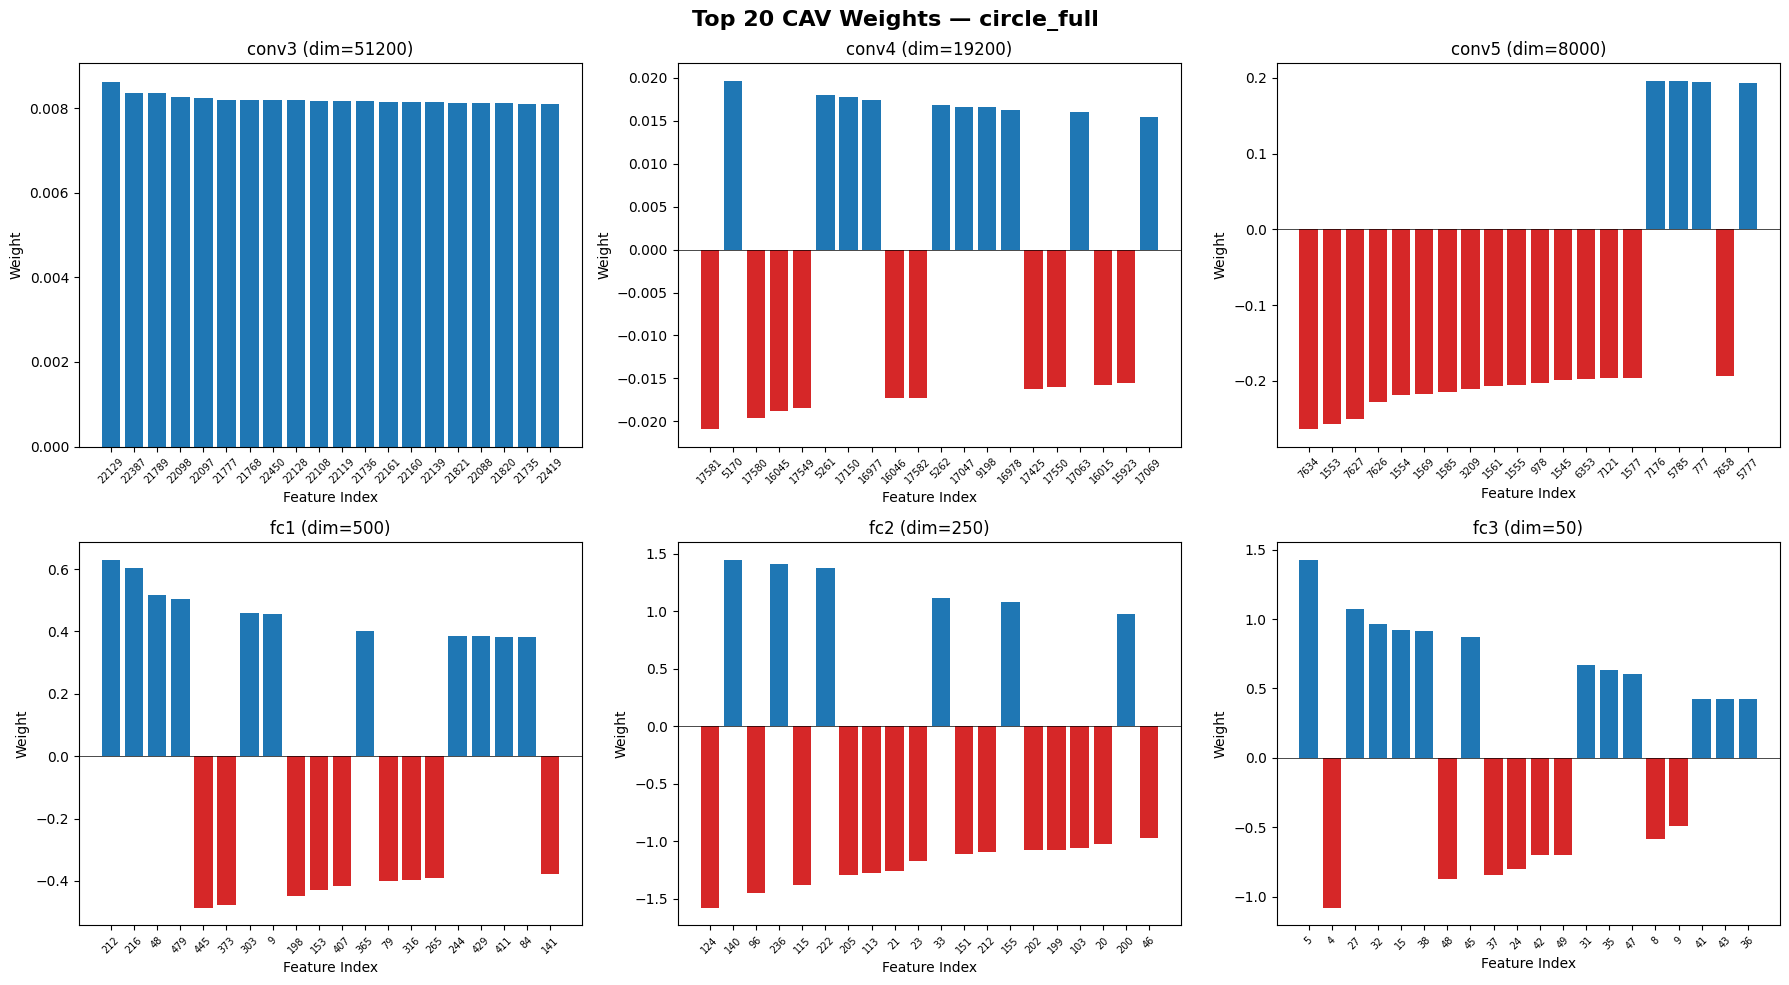

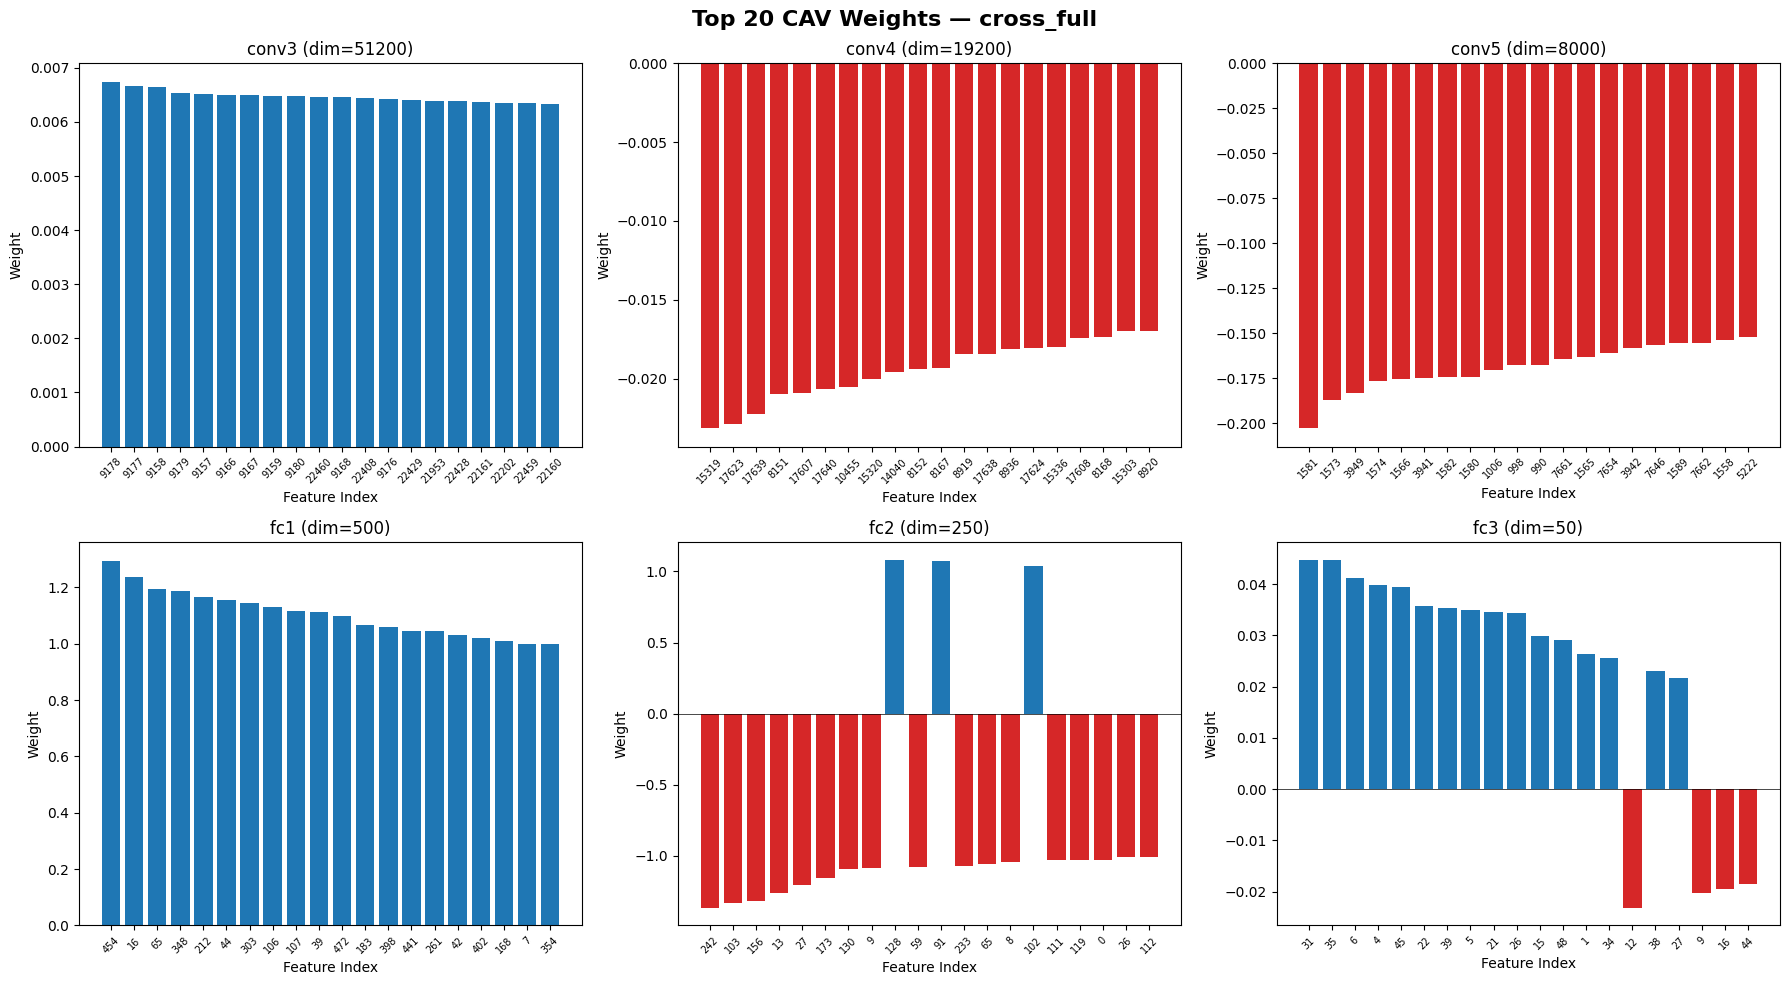

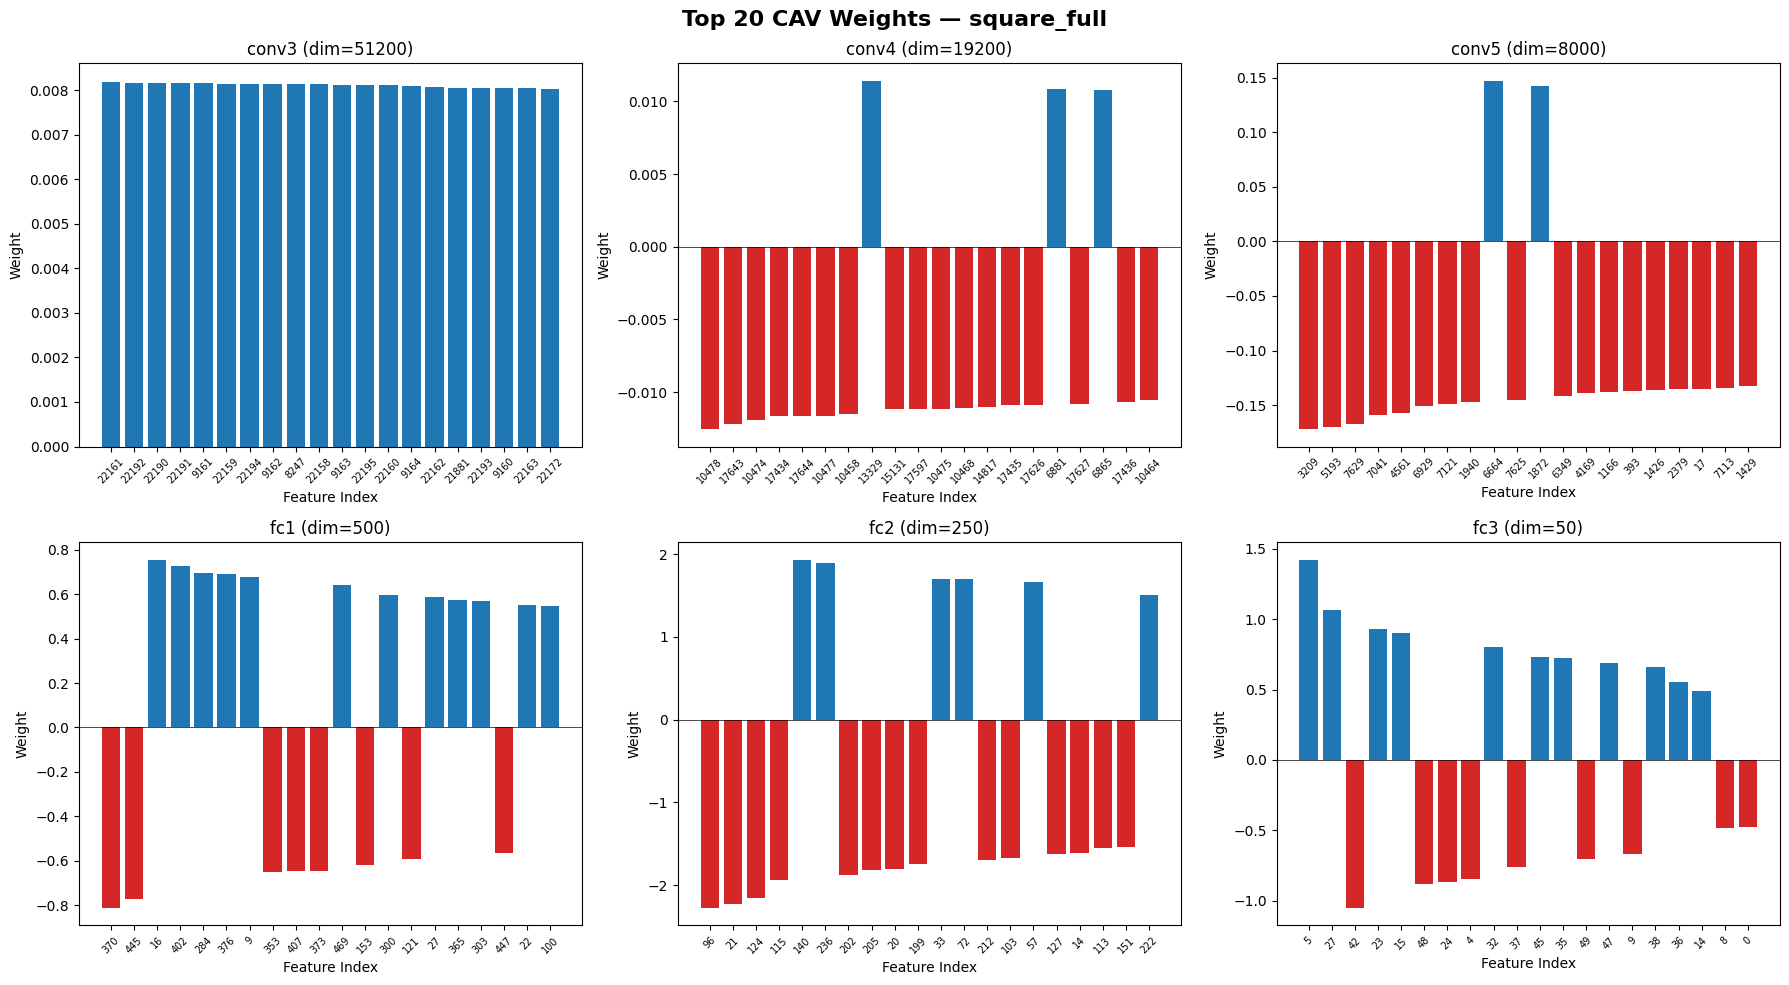

In [22]:
# ==========================================
# 7. Plot Top-N CAV weights per concept × layer
# ==========================================
TOP_N = 20

for concept_name in cav_weights:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Top {TOP_N} CAV Weights — {concept_name}", fontsize=16, fontweight='bold')
    
    for idx, layer_name in enumerate(LAYERS):
        ax = axes[idx // 3][idx % 3]
        w = cav_weights[concept_name][layer_name]
        
        sorted_idx = np.argsort(np.abs(w))[::-1][:TOP_N]
        top_w = w[sorted_idx]
        
        colors = ['tab:blue' if v >= 0 else 'tab:red' for v in top_w]
        ax.bar(range(TOP_N), top_w, color=colors)
        ax.set_xticks(range(TOP_N))
        ax.set_xticklabels(sorted_idx, rotation=45, fontsize=7)
        ax.set_title(f"{layer_name} (dim={w.shape[0]})")
        ax.set_xlabel("Feature Index")
        ax.set_ylabel("Weight")
        ax.axhline(y=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

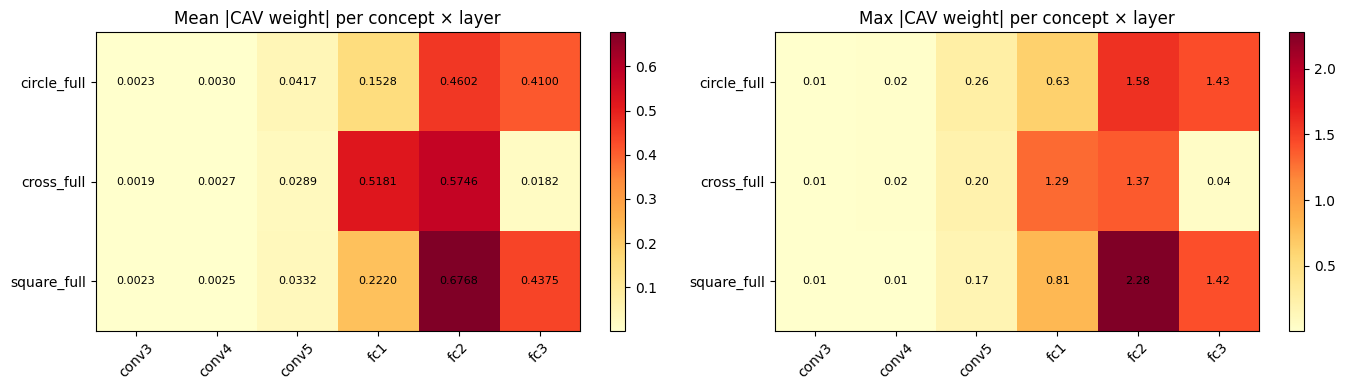

In [23]:
# ==========================================
# 8. Heatmap: mean |weight| per concept × layer
# ==========================================
concept_names = list(cav_weights.keys())

# Compute summary statistics
mean_abs = np.zeros((len(concept_names), len(LAYERS)))
max_abs  = np.zeros((len(concept_names), len(LAYERS)))

for i, cn in enumerate(concept_names):
    for j, ln in enumerate(LAYERS):
        w = cav_weights[cn][ln]
        mean_abs[i, j] = np.abs(w).mean()
        max_abs[i, j]  = np.abs(w).max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

im1 = ax1.imshow(mean_abs, aspect='auto', cmap='YlOrRd')
ax1.set_xticks(range(len(LAYERS)))
ax1.set_xticklabels(LAYERS, rotation=45)
ax1.set_yticks(range(len(concept_names)))
ax1.set_yticklabels(concept_names)
ax1.set_title("Mean |CAV weight| per concept × layer")
for i in range(len(concept_names)):
    for j in range(len(LAYERS)):
        ax1.text(j, i, f"{mean_abs[i,j]:.4f}", ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(max_abs, aspect='auto', cmap='YlOrRd')
ax2.set_xticks(range(len(LAYERS)))
ax2.set_xticklabels(LAYERS, rotation=45)
ax2.set_yticks(range(len(concept_names)))
ax2.set_yticklabels(concept_names)
ax2.set_title("Max |CAV weight| per concept × layer")
for i in range(len(concept_names)):
    for j in range(len(LAYERS)):
        ax2.text(j, i, f"{max_abs[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# 9. Load validation images and classify with model
# ==========================================
# Model predicts: 1.0 = "has circles" / 0.0 = "square-dominant, no circles"
# label=0 iff (c==0 AND s>0 AND s>=cr)
import glob as glob_mod

val_dir = "data/aixi_shape/val/"
val_paths = sorted(glob_mod.glob(val_dir + "*.png"))[:200]  # first 200 for speed

# Load and classify
val_tensors = []
for p in val_paths:
    img = Image.open(p).convert("L")
    t = transform(img)
    val_tensors.append(t)

val_batch = torch.stack(val_tensors).to(DEVICE)
with torch.no_grad():
    preds = model(val_batch).squeeze()
    
# Split by model prediction
circle_mask = preds > 0.5       # pred ≈ 1.0 → has circles
sq_dominant_mask = preds <= 0.5  # pred ≈ 0.0 → square-dominant, no circles

print(f"Total val images loaded: {len(val_paths)}")
print(f"  Predicted as 'has circles' (>0.5): {circle_mask.sum().item()}")
print(f"  Predicted as 'sq-dominant, no circles' (<=0.5): {sq_dominant_mask.sum().item()}")

# Take a sample batch from each group for TCAV scoring
N_SAMPLES = 20
x_circle = val_batch[circle_mask][:N_SAMPLES]
x_sq_dominant = val_batch[sq_dominant_mask][:N_SAMPLES]

print(f"\nSample batch sizes: circle={x_circle.shape[0]}, sq_dominant={x_sq_dominant.shape[0]}")

Total val images loaded: 200
  Predicted as 'has circles' (>0.5): 138
  Predicted as 'sq-dominant, no circles' (<=0.5): 62

Sample batch sizes: circle=20, sq_dominant=20


In [25]:
# ==========================================
# 10. TCAV interpret scores — circle images vs square-dominant images
# ==========================================
from captum.concept import TCAV
from captum.attr import LayerIntegratedGradients

# Recreate TCAV for scoring (CAVs are cached)
mytcav_score = TCAV(model=model, layers=LAYERS)

sample_groups = {
    "circle_images": x_circle,            # pred > 0.5 (has circles)
    "sq_dominant_images": x_sq_dominant,   # pred <= 0.5 (square-dominant, no circles)
}

tcav_scores = {}
for group_name, x_input in sample_groups.items():
    print(f"\n=== TCAV scores for '{group_name}' (batch={x_input.shape[0]}) ===")
    scores = mytcav_score.interpret(
        inputs=x_input,
        experimental_sets=experimental_sets,
        target=0,
    )
    tcav_scores[group_name] = scores
    
    for exp_key, layer_data in scores.items():
        concept_name = key_to_concept.get(exp_key, exp_key)
        print(f"\n  {concept_name} ({exp_key}):")
        for layer_name, stats in layer_data.items():
            sc = stats.get('sign_count', None)
            mag = stats.get('magnitude', None)
            if sc is not None:
                pos, neg = sc[0].item(), sc[1].item()
                total = pos + neg
                rate = pos / total if total > 0 else 0
                print(f"    {layer_name}: pos={pos:.0f}, neg={neg:.0f}, rate={rate:.2f}")


=== TCAV scores for 'circle_images' (batch=20) ===


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()



  circle_full (0-100):
    conv3: pos=0, neg=0, rate=0.00
    conv4: pos=0, neg=0, rate=0.00
    conv5: pos=0, neg=0, rate=0.00
    fc1: pos=0, neg=0, rate=0.00
    fc2: pos=0, neg=0, rate=0.00
    fc3: pos=0, neg=0, rate=0.00

  cross_full (1-100):
    conv3: pos=0, neg=0, rate=0.00
    conv4: pos=0, neg=0, rate=0.00
    conv5: pos=0, neg=0, rate=0.00
    fc1: pos=0, neg=0, rate=0.00
    fc2: pos=0, neg=0, rate=0.00
    fc3: pos=0, neg=0, rate=0.00

  square_full (2-100):
    conv3: pos=0, neg=0, rate=0.00
    conv4: pos=0, neg=0, rate=0.00
    conv5: pos=0, neg=0, rate=0.00
    fc1: pos=0, neg=0, rate=0.00
    fc2: pos=0, neg=0, rate=0.00
    fc3: pos=0, neg=0, rate=0.00

=== TCAV scores for 'sq_dominant_images' (batch=20) ===

  circle_full (0-100):
    conv3: pos=1, neg=0, rate=0.85
    conv4: pos=1, neg=0, rate=1.00
    conv5: pos=1, neg=0, rate=1.00
    fc1: pos=0, neg=1, rate=0.00
    fc2: pos=0, neg=1, rate=0.00
    fc3: pos=0, neg=1, rate=0.00

  cross_full (1-100):
    conv3

### Note on zero TCAV scores for `circle_images`

The model uses **sigmoid** as its final activation and predicts **1.0 = "has circles"**. For circle images (pred ≈ 1.0), the sigmoid gradient vanishes (sigmoid'(x) → 0 when x is large). Since TCAV uses `LayerGradientXActivation` by default, near-zero gradients produce near-zero TCAV scores.

This is a known limitation: **TCAV scores are unreliable for saturated sigmoid outputs**. The `sq_dominant_images` scores are meaningful because predictions are in the sigmoid transition region where gradients flow.

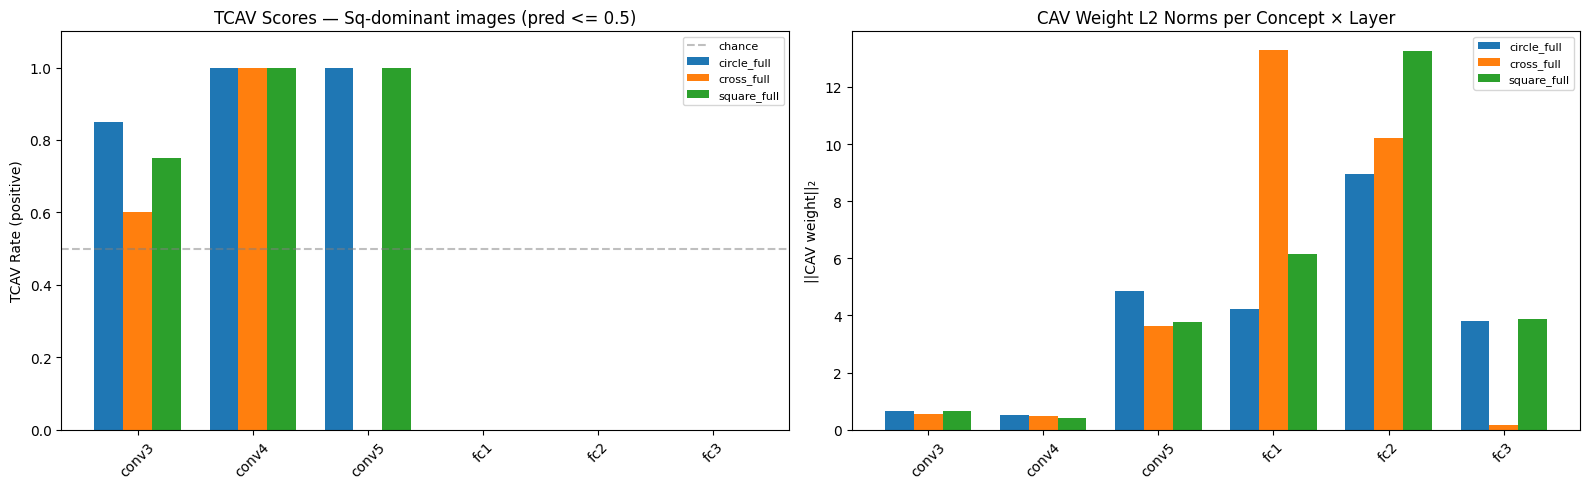

In [26]:
# ==========================================
# 11. Visualize TCAV scores for sq-dominant images
# ==========================================
concept_names_list = ['circle_full', 'cross_full', 'square_full']
exp_keys = ['0-100', '1-100', '2-100']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: TCAV rates (sq_dominant only, since circle_images gives all zeros)
ax = axes[0]
x_pos = np.arange(len(LAYERS))
width = 0.25

scores_data = tcav_scores['sq_dominant_images']
for i, (ek, cn) in enumerate(zip(exp_keys, concept_names_list)):
    rates = []
    for layer in LAYERS:
        sc = scores_data[ek][layer]['sign_count']
        pos, neg = sc[0].item(), sc[1].item()
        total = pos + neg
        rates.append(pos / total if total > 0 else 0)
    ax.bar(x_pos + i * width, rates, width, label=cn)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(LAYERS, rotation=45)
ax.set_ylabel('TCAV Rate (positive)')
ax.set_title('TCAV Scores — Sq-dominant images (pred <= 0.5)')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
ax.legend(fontsize=8)

# Plot 2: CAV weight norms per concept × layer (from extracted weights)
ax2 = axes[1]
for i, cn in enumerate(concept_names_list):
    norms = [np.linalg.norm(cav_weights[cn][l]) for l in LAYERS]
    ax2.bar(x_pos + i * width, norms, width, label=cn)

ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(LAYERS, rotation=45)
ax2.set_ylabel('||CAV weight||₂')
ax2.set_title('CAV Weight L2 Norms per Concept × Layer')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Feature Map Visualization (Post-MaxPool Activations)

By hooking into the maxpool layers and passing concept images through TNet, we can visualize the spatial activation patterns and verify that the network is actually detecting the geometric concepts (circles, squares, crosses).

In [27]:
# ==========================================
# 12. Hook into maxpool layers to capture activations
# ==========================================

# Storage for captured activations
activations = {}

def make_hook(name):
    def hook_fn(module, input, output):
        activations[name] = output.detach()
    return hook_fn

# Register hooks on maxpool layers (after each conv block)
hook_layers = {
    'maxpool1': model.maxpool1,  # after conv1: 25 channels, 64x64
    'maxpool2': model.maxpool2,  # after conv2: 35 channels, 32x32
    'maxpool3': model.maxpool3,  # after conv3: 50 channels, 16x16
    'maxpool4': model.maxpool4,  # after conv4: 75 channels, 8x8
    'maxpool5': model.maxpool5,  # after conv5: 125 channels, 4x4
}

hooks = []
for name, layer in hook_layers.items():
    hooks.append(layer.register_forward_hook(make_hook(name)))

print(f"Registered {len(hooks)} forward hooks on maxpool layers")

Registered 5 forward hooks on maxpool layers


In [28]:
# ==========================================
# 13. Pass sample concept images through the model
# ==========================================
import glob as glob_mod

concept_samples = {}
concepts_path = "./data/concepts"

for concept_name in ['circle_full', 'cross_full', 'square_full']:
    # Load first image from each concept directory
    img_paths = sorted(glob_mod.glob(os.path.join(concepts_path, concept_name, "*.png")))
    if not img_paths:
        img_paths = sorted(glob_mod.glob(os.path.join(concepts_path, concept_name, "*.jpg")))
    
    img = Image.open(img_paths[0]).convert("L")
    t = transform(img).unsqueeze(0).to(DEVICE)
    
    # Forward pass to capture activations
    activations.clear()
    with torch.no_grad():
        pred = model(t)
    
    concept_samples[concept_name] = {
        'image': img,
        'tensor': t,
        'pred': pred.item(),
        'activations': dict(activations),  # copy the captured activations
    }
    
    print(f"{concept_name}: pred={pred.item():.4f}, activation shapes:")
    for layer_name, act in concept_samples[concept_name]['activations'].items():
        print(f"  {layer_name}: {act.shape}")

circle_full: pred=1.0000, activation shapes:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])
cross_full: pred=0.0000, activation shapes:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])
square_full: pred=0.0000, activation shapes:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])


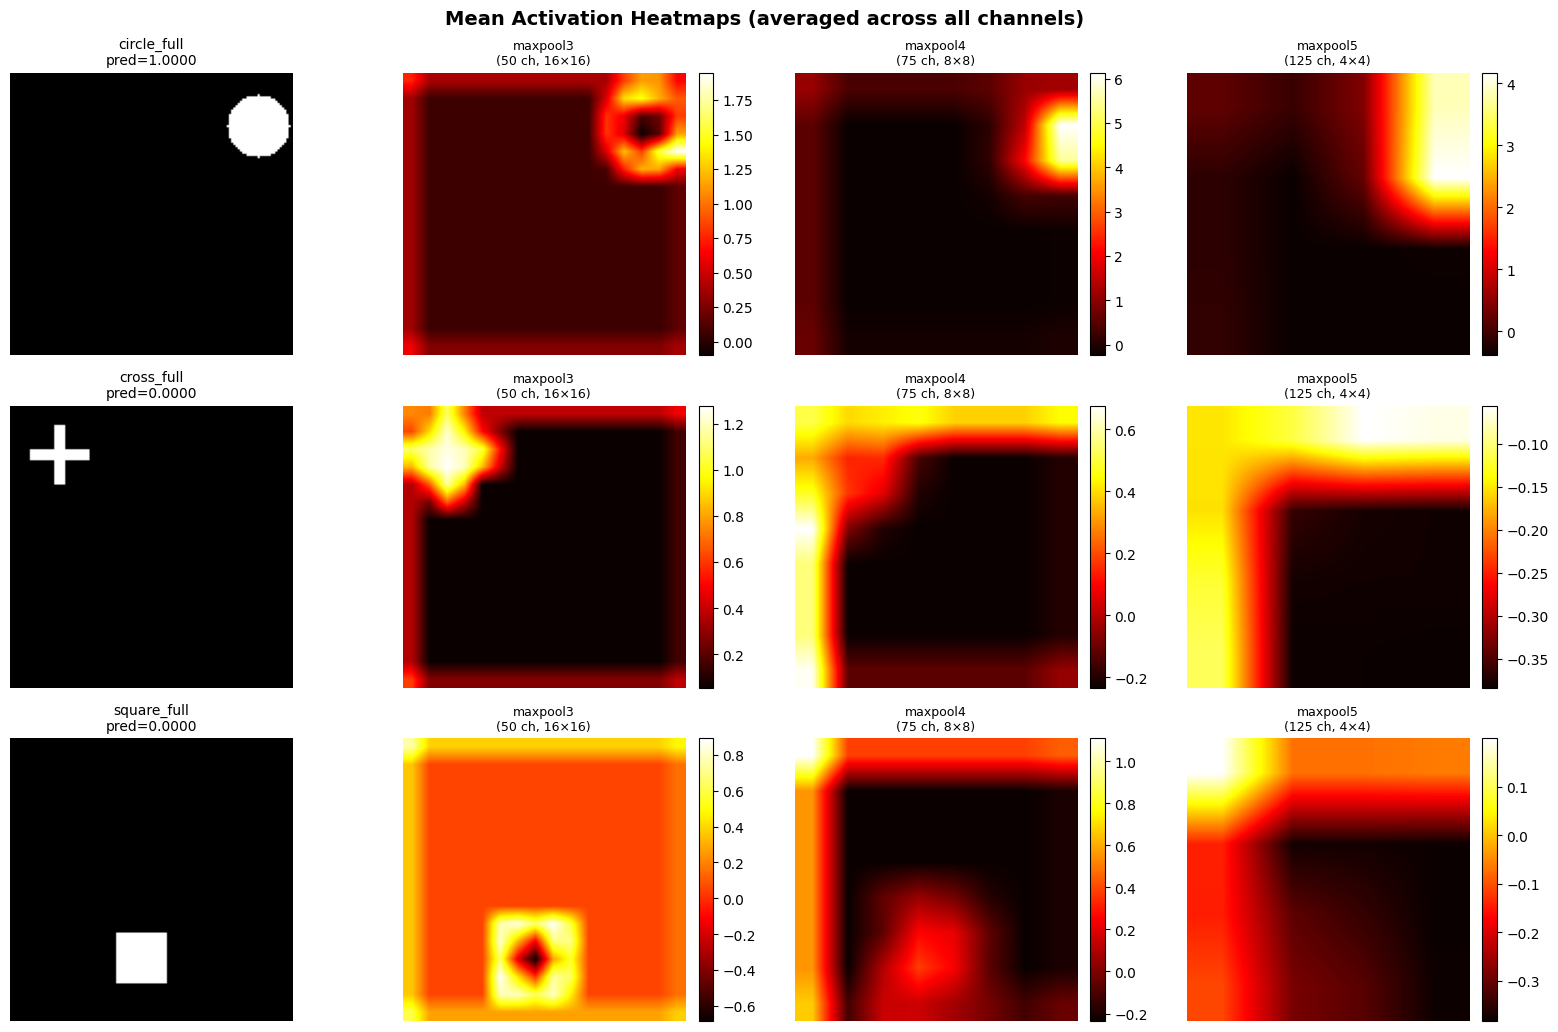

In [29]:
# ==========================================
# 14. Visualize mean activation heatmaps per concept × maxpool layer
# ==========================================
concept_names_list = ['circle_full', 'cross_full', 'square_full']
layer_names = ['maxpool3', 'maxpool4', 'maxpool5']  # mid-to-late conv layers (most informative)

fig, axes = plt.subplots(len(concept_names_list), len(layer_names) + 1, 
                         figsize=(16, 3.5 * len(concept_names_list)))

for i, cn in enumerate(concept_names_list):
    # Show original image
    ax = axes[i][0]
    ax.imshow(concept_samples[cn]['image'], cmap='gray')
    ax.set_title(f"{cn}\npred={concept_samples[cn]['pred']:.4f}", fontsize=10)
    ax.axis('off')
    
    # Show mean activation heatmap for each layer
    for j, ln in enumerate(layer_names):
        ax = axes[i][j + 1]
        act = concept_samples[cn]['activations'][ln]  # [1, C, H, W]
        
        # Mean across all channels -> [H, W]
        mean_act = act[0].mean(dim=0).numpy()
        
        im = ax.imshow(mean_act, cmap='hot', interpolation='bilinear')
        ax.set_title(f"{ln}\n({act.shape[1]} ch, {act.shape[2]}×{act.shape[3]})", fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Mean Activation Heatmaps (averaged across all channels)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

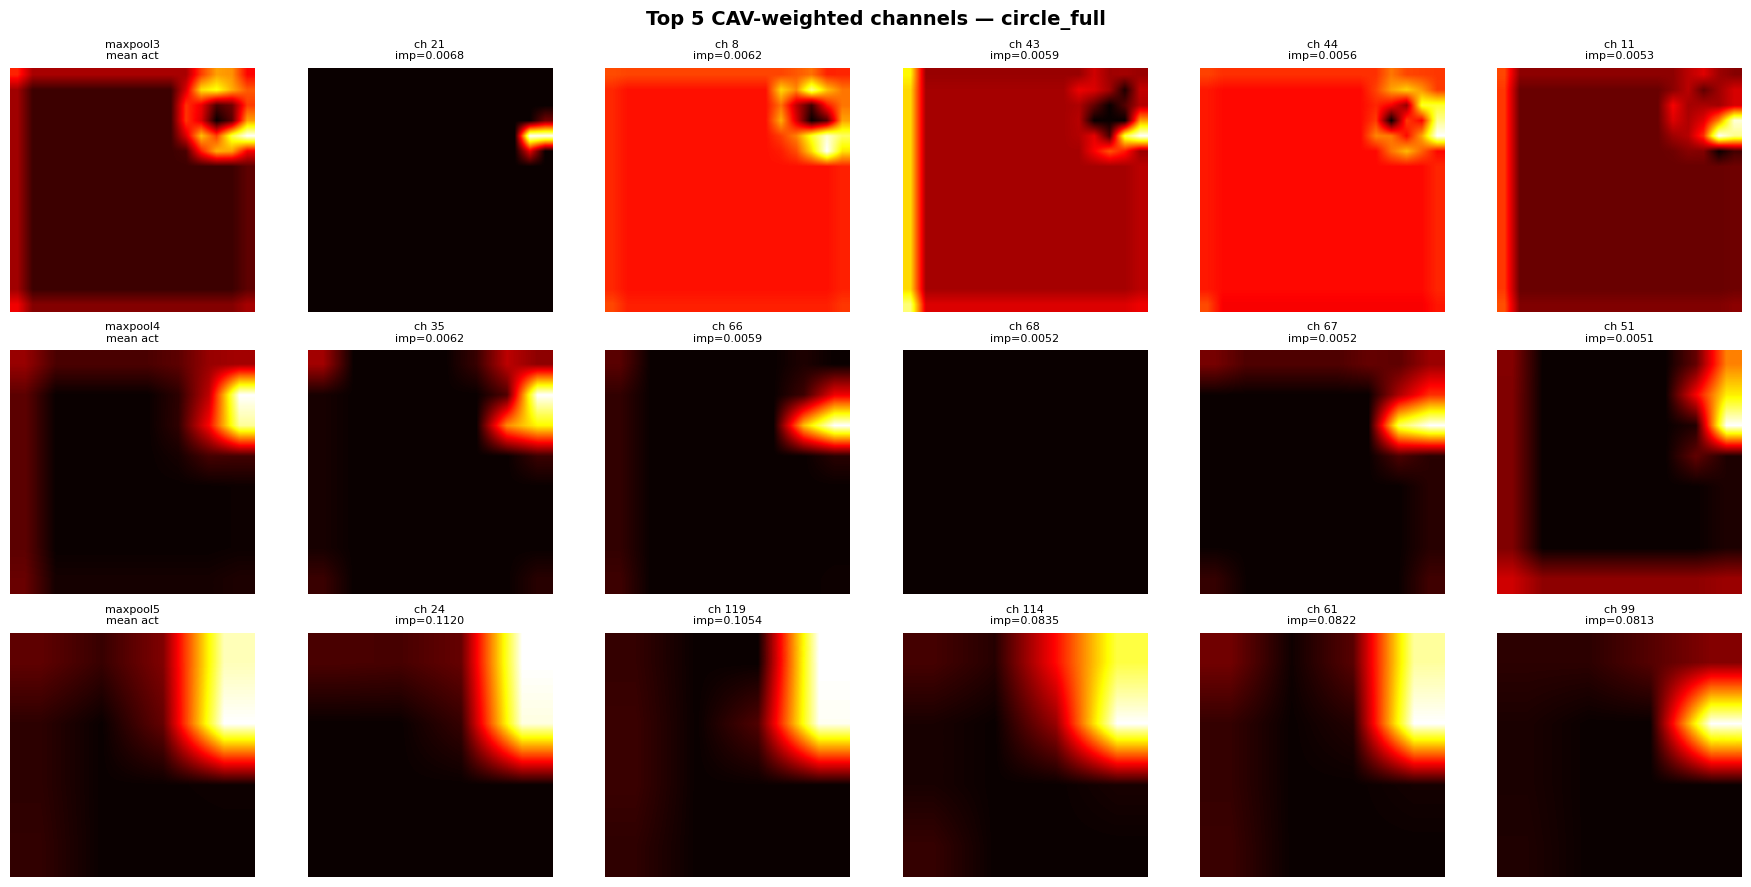

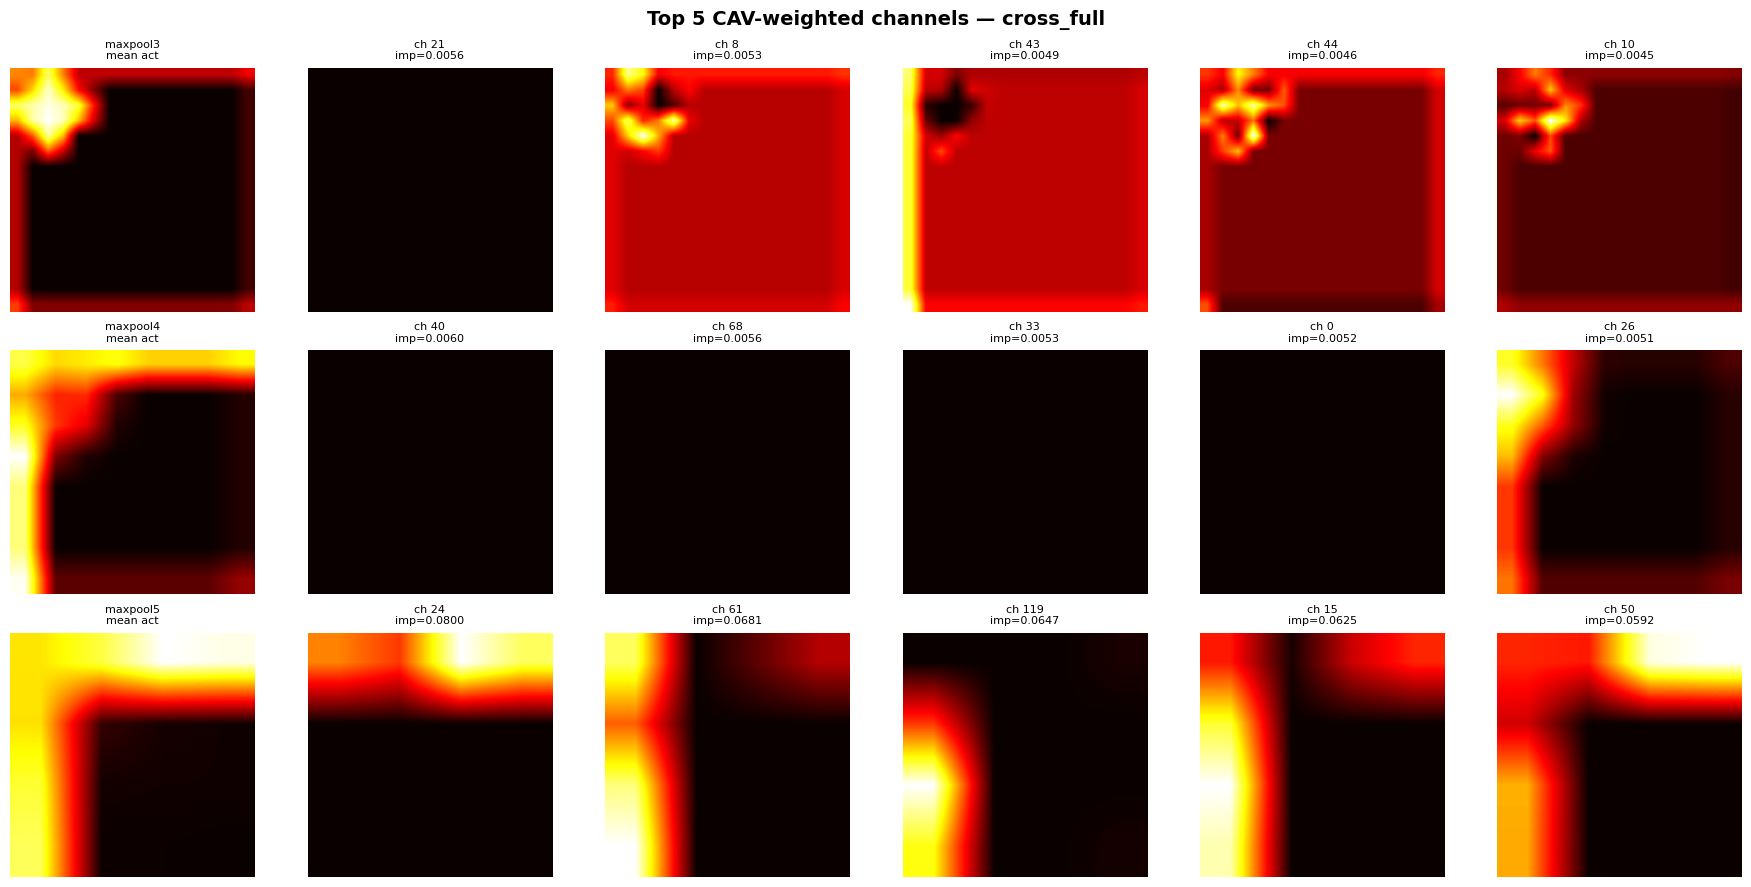

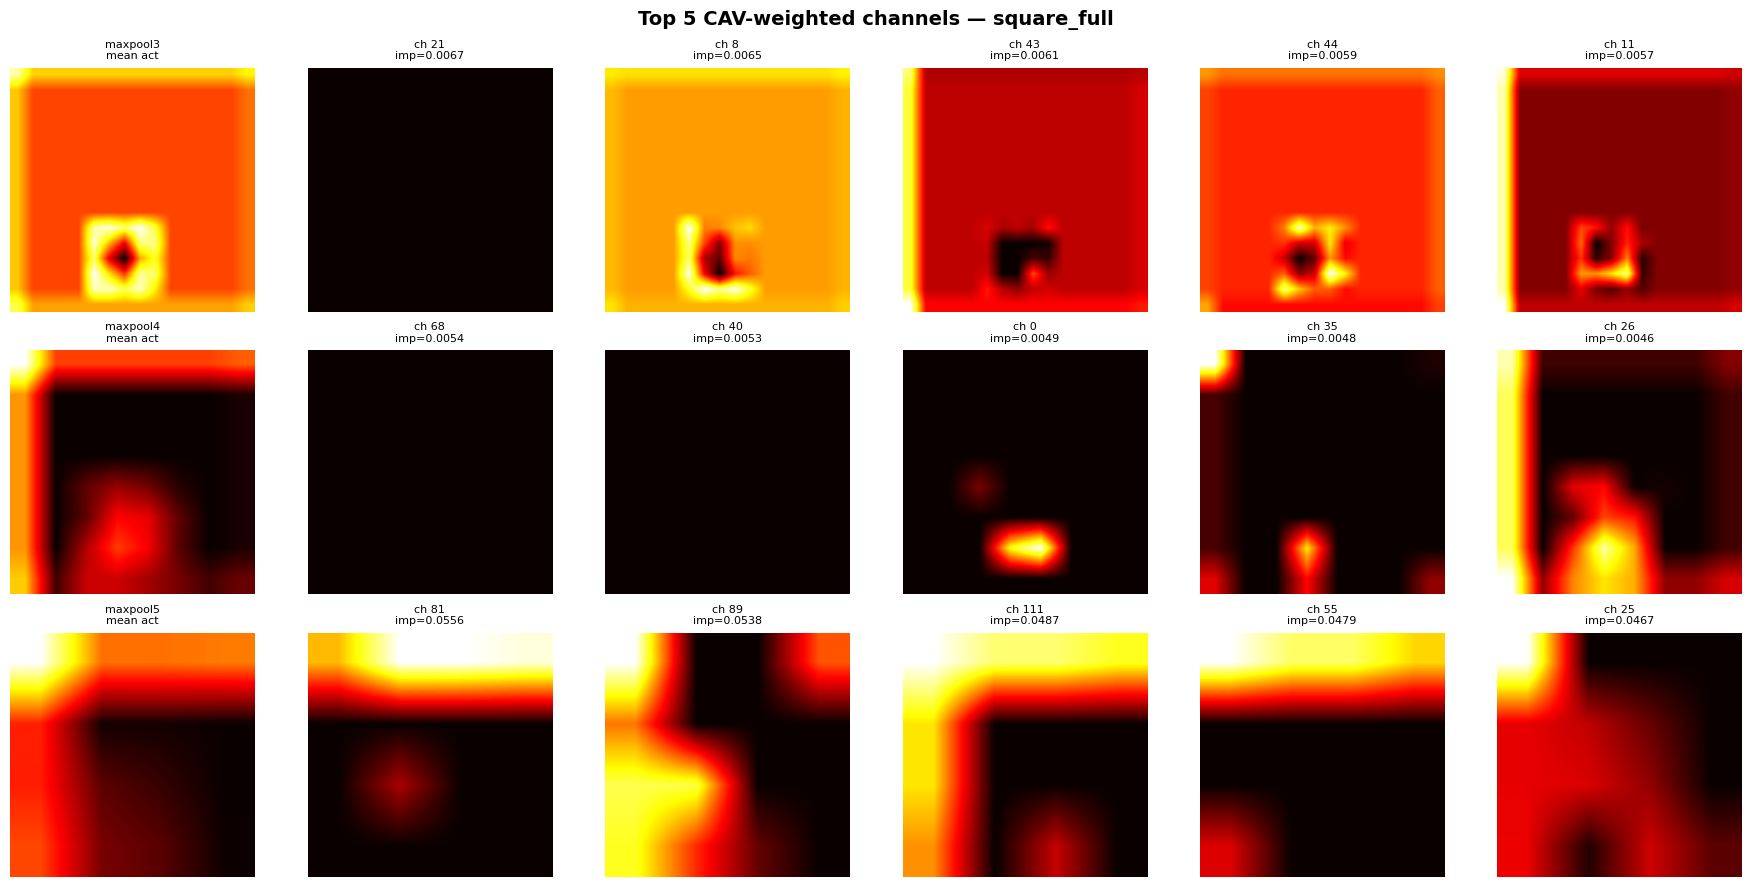

In [30]:
# ==========================================
# 15. Visualize top CAV-weighted channels per concept
# ==========================================
# CAV weights correspond to conv layer outputs (BEFORE maxpool).
# Spatial dims: conv3=32x32, conv4=16x16, conv5=8x8
# But we visualize the maxpool outputs (which halve spatial dims).
# We just need per-channel importance from the CAV weights.

maxpool_to_cav = {
    'maxpool3': ('conv3', 50),   # 50 channels
    'maxpool4': ('conv4', 75),   # 75 channels
    'maxpool5': ('conv5', 125),  # 125 channels
}

TOP_K = 5  # top channels to visualize

for cn in concept_names_list:
    fig, axes = plt.subplots(len(maxpool_to_cav), TOP_K + 1, 
                             figsize=(3 * (TOP_K + 1), 3 * len(maxpool_to_cav)))
    fig.suptitle(f"Top {TOP_K} CAV-weighted channels — {cn}", fontsize=14, fontweight='bold')
    
    for row, (mp_layer, (cav_layer, n_channels)) in enumerate(maxpool_to_cav.items()):
        act = concept_samples[cn]['activations'][mp_layer]  # [1, C, H, W]
        
        # Get CAV weights and compute per-channel importance
        w = cav_weights[cn][cav_layer]
        # w is flattened [C * H_conv * W_conv], reshape to [C, -1] and aggregate
        spatial_size = len(w) // n_channels
        w_reshaped = w.reshape(n_channels, spatial_size)
        channel_importance = np.abs(w_reshaped).mean(axis=1)
        
        top_channels = np.argsort(channel_importance)[::-1][:TOP_K]
        
        # Show mean activation in first column
        ax = axes[row][0]
        mean_act = act[0].mean(dim=0).numpy()
        im = ax.imshow(mean_act, cmap='hot', interpolation='bilinear')
        ax.set_title(f"{mp_layer}\nmean act", fontsize=8)
        ax.axis('off')
        
        # Show top individual channel activations
        for k, ch_idx in enumerate(top_channels):
            ax = axes[row][k + 1]
            ch_act = act[0, ch_idx].numpy()
            im = ax.imshow(ch_act, cmap='hot', interpolation='bilinear')
            ax.set_title(f"ch {ch_idx}\nimp={channel_importance[ch_idx]:.4f}", fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()

## CAV-Projected Concept Heatmaps on Validation Images

**Key idea:** In layers where TCAV score is high for a concept (from cell 11), project the CAV direction onto the activation space to create a spatial heatmap showing *where* in the image the concept's features are being detected.

For each spatial position (h, w), we compute:  
`heatmap(h,w) = Σ_c importance(c) × activation(c, h, w)`

where `importance(c)` is derived from the CAV weights, telling us how much each channel contributes to the concept direction.

**From the TCAV scores (sq-dominant images, pred ≤ 0.5):**
- `circle_full`: high in conv3 (0.85), conv4 (1.00), conv5 (1.00)
- `cross_full`: high in conv3 (0.60), conv4 (1.00)
- `square_full`: high in conv3 (0.75), conv4 (1.00), conv5 (1.00)

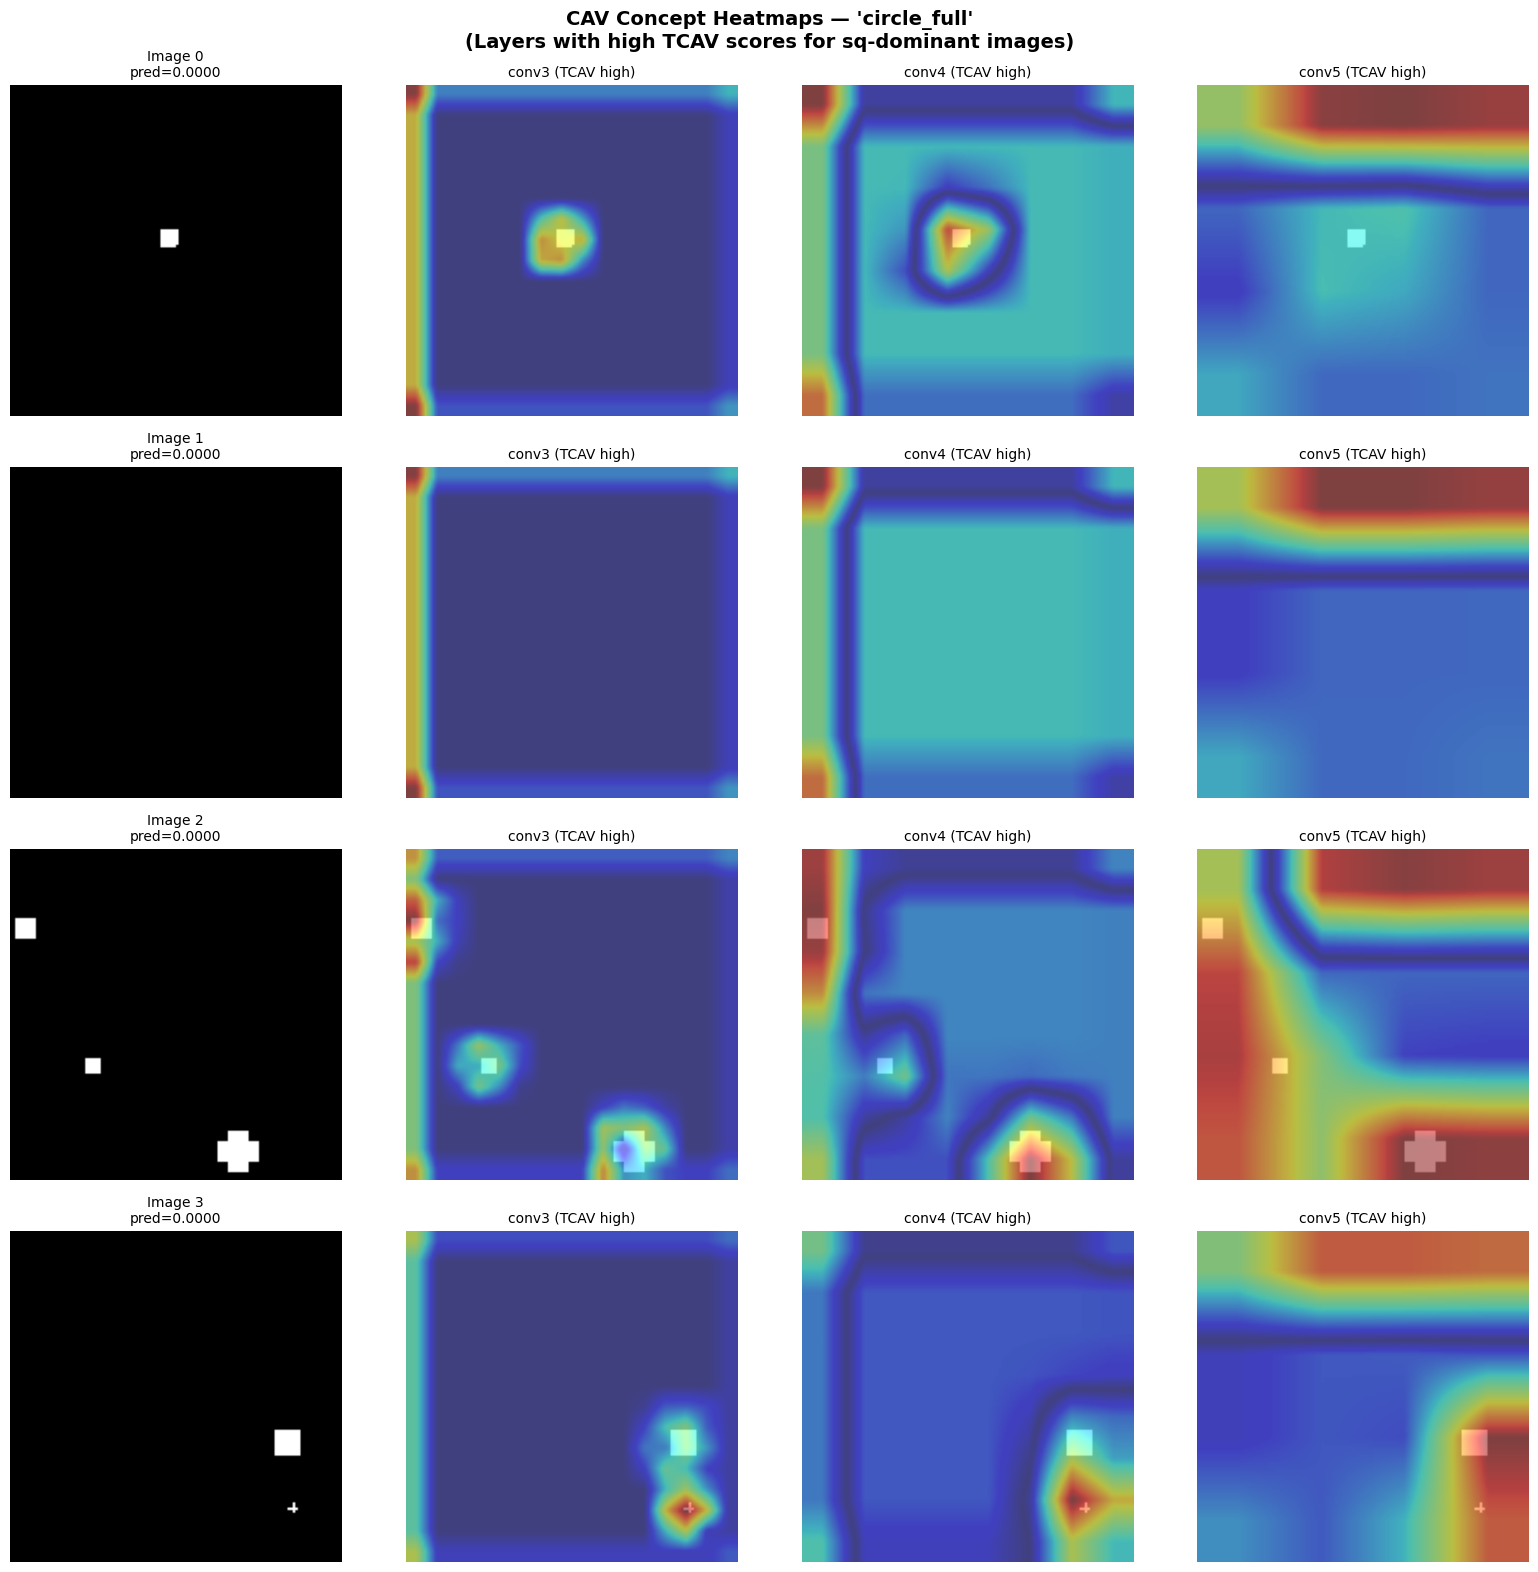

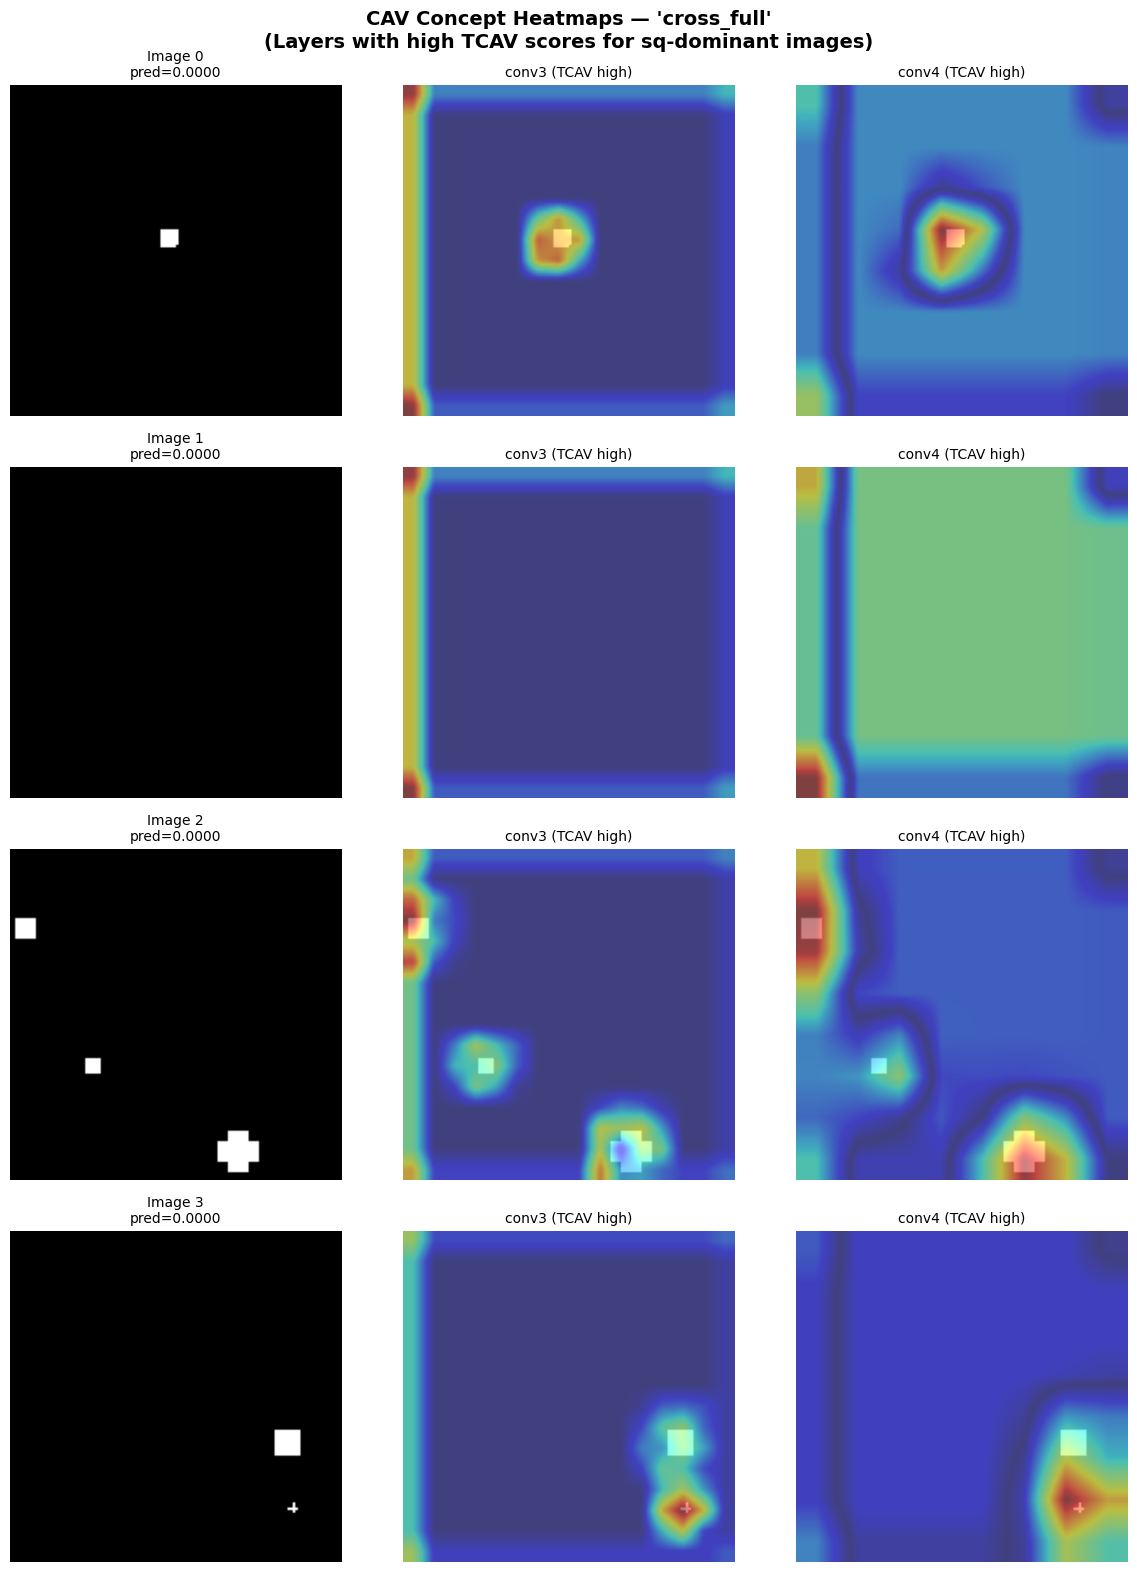

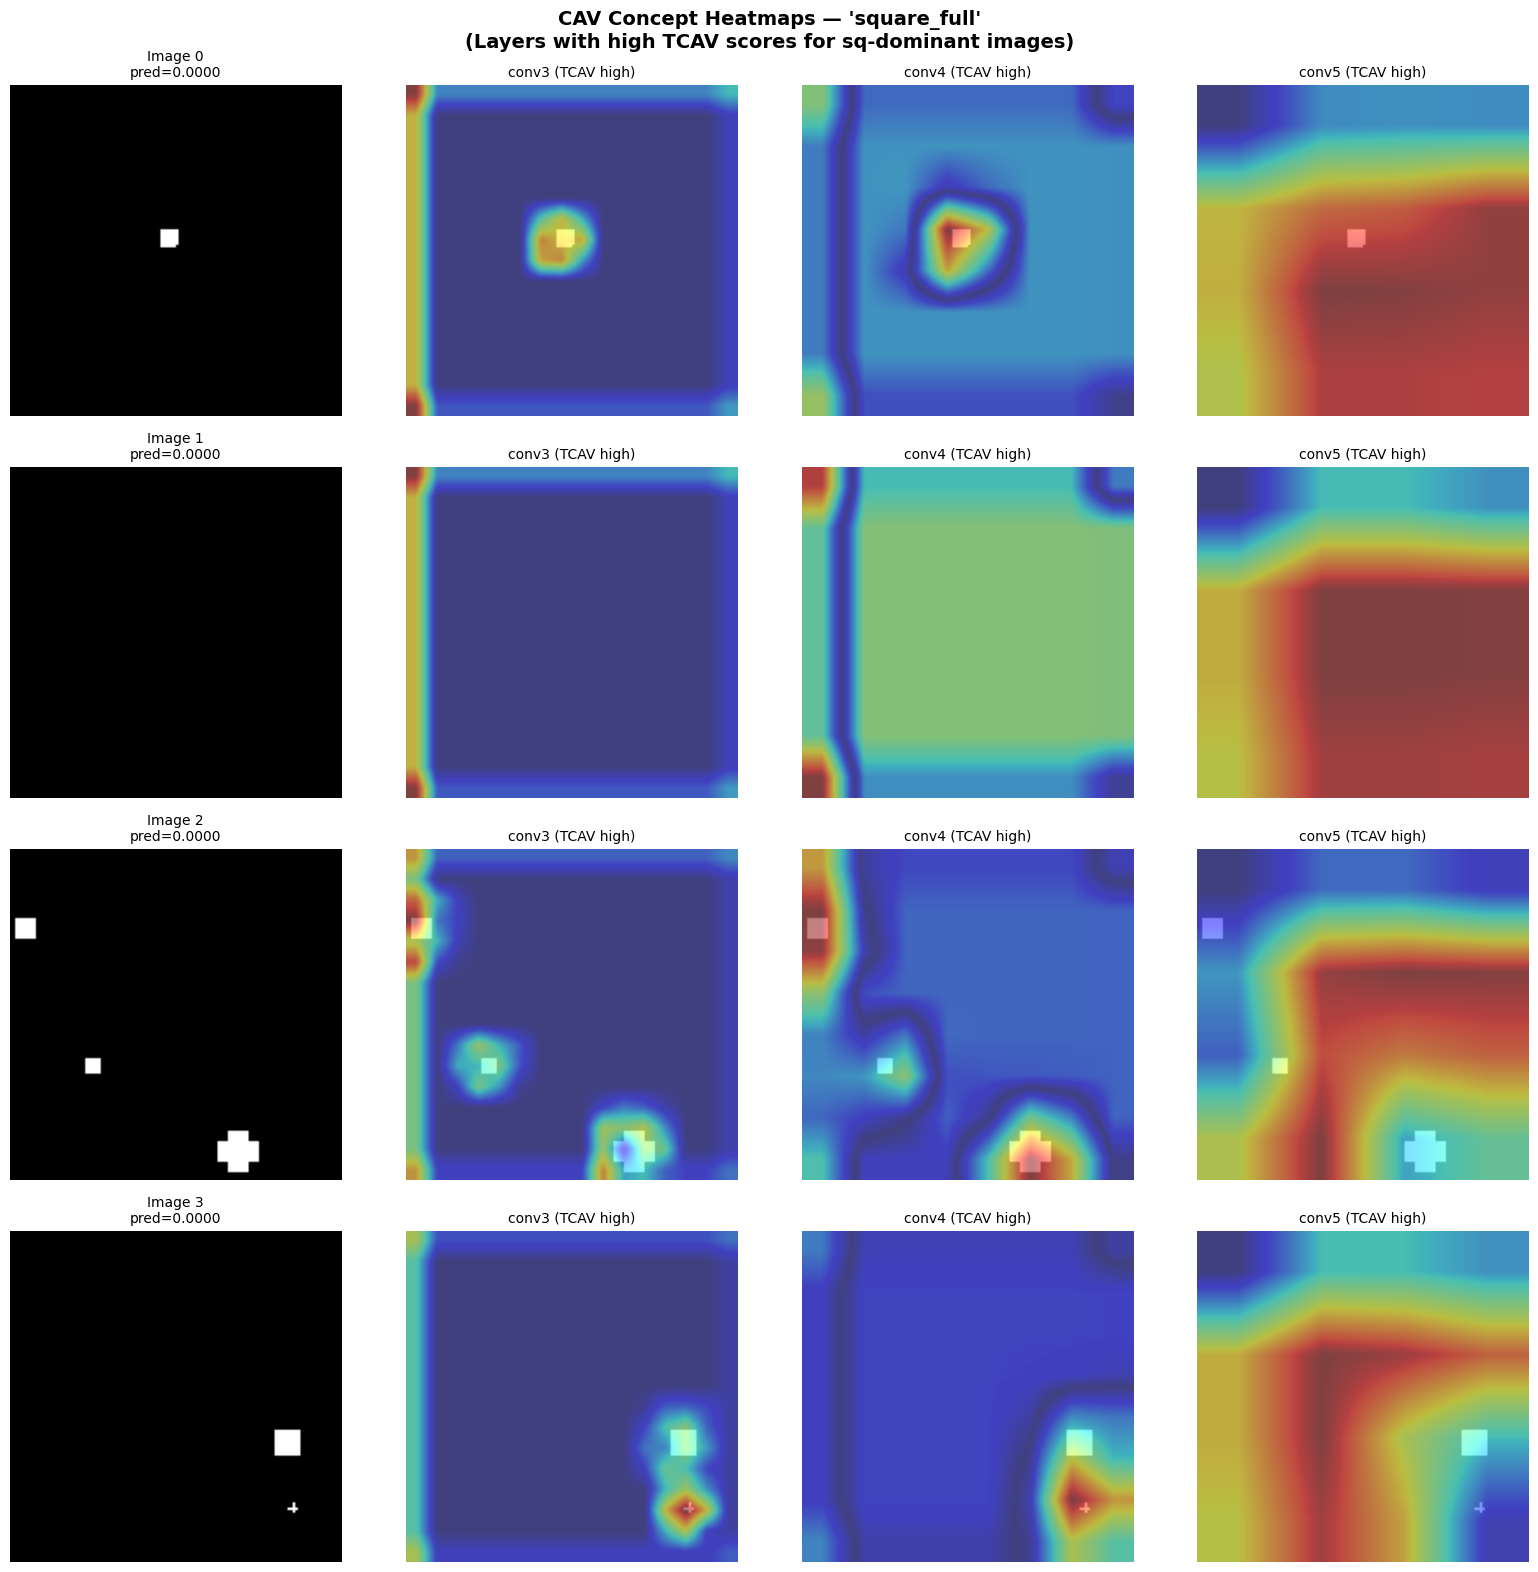

In [31]:
# ==========================================
# 16. CAV-projected heatmaps on sq-dominant validation images
# ==========================================
# Show concept features highlighted in layers where TCAV score is high
import torch.nn.functional as F

# Define which concept × layer pairs had high TCAV rates (from cell 11)
high_tcav_pairs = {
    'circle_full':  ['conv3', 'conv4', 'conv5'],   # rates: 0.85, 1.00, 1.00
    'cross_full':   ['conv3', 'conv4'],             # rates: 0.60, 1.00
    'square_full':  ['conv3', 'conv4', 'conv5'],   # rates: 0.75, 1.00, 1.00
}

# Map conv layer -> corresponding maxpool layer (for activations) and channel count
conv_to_maxpool = {
    'conv3': ('maxpool3', 50),
    'conv4': ('maxpool4', 75),
    'conv5': ('maxpool5', 125),
}

# Pick some sq-dominant validation images to visualize
N_VIS = 4
vis_images = x_sq_dominant[:N_VIS]  # [N, 1, 128, 128]

# Forward pass to capture activations (hooks are still registered)
model.eval()
with torch.no_grad():
    vis_preds = model(vis_images).squeeze()

# For each concept, show the CAV-projected heatmaps overlaid on the original images
for concept_name, high_layers in high_tcav_pairs.items():
    n_layers = len(high_layers)
    fig, axes = plt.subplots(N_VIS, n_layers + 1, figsize=(4 * (n_layers + 1), 4 * N_VIS))
    fig.suptitle(f"CAV Concept Heatmaps — '{concept_name}'\n(Layers with high TCAV scores for sq-dominant images)", 
                 fontsize=14, fontweight='bold')
    
    for img_idx in range(N_VIS):
        # Show original image in first column
        ax = axes[img_idx][0]
        orig = vis_images[img_idx, 0].cpu().numpy()
        ax.imshow(orig, cmap='gray')
        pred_val = vis_preds[img_idx].item() if vis_preds.dim() > 0 else vis_preds.item()
        ax.set_title(f"Image {img_idx}\npred={pred_val:.4f}", fontsize=10)
        ax.axis('off')
        
        for col, conv_layer in enumerate(high_layers):
            mp_layer, n_channels = conv_to_maxpool[conv_layer]
            act = activations[mp_layer]  # [N, C, H, W]
            
            # Get per-channel CAV importance
            w = cav_weights[concept_name][conv_layer]
            spatial_size = len(w) // n_channels
            w_reshaped = w.reshape(n_channels, spatial_size)
            channel_importance = w_reshaped.mean(axis=1)  # signed importance per channel
            
            # Compute CAV-projected heatmap: weighted sum of activation channels
            act_img = act[img_idx].cpu().numpy()  # [C, H, W]
            heatmap = np.zeros(act_img.shape[1:])  # [H, W]
            for c in range(n_channels):
                heatmap += channel_importance[c] * act_img[c]
            
            # Upsample heatmap to original image size for overlay
            heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
            heatmap_upsampled = F.interpolate(heatmap_tensor, size=(128, 128), 
                                               mode='bilinear', align_corners=False)
            heatmap_up = heatmap_upsampled.squeeze().numpy()
            
            # Normalize for visualization
            hm_abs = np.abs(heatmap_up)
            if hm_abs.max() > 0:
                hm_abs = hm_abs / hm_abs.max()
            
            ax = axes[img_idx][col + 1]
            ax.imshow(orig, cmap='gray', alpha=0.5)
            ax.imshow(hm_abs, cmap='jet', alpha=0.5, interpolation='bilinear')
            ax.set_title(f"{conv_layer} (TCAV high)", fontsize=10)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()

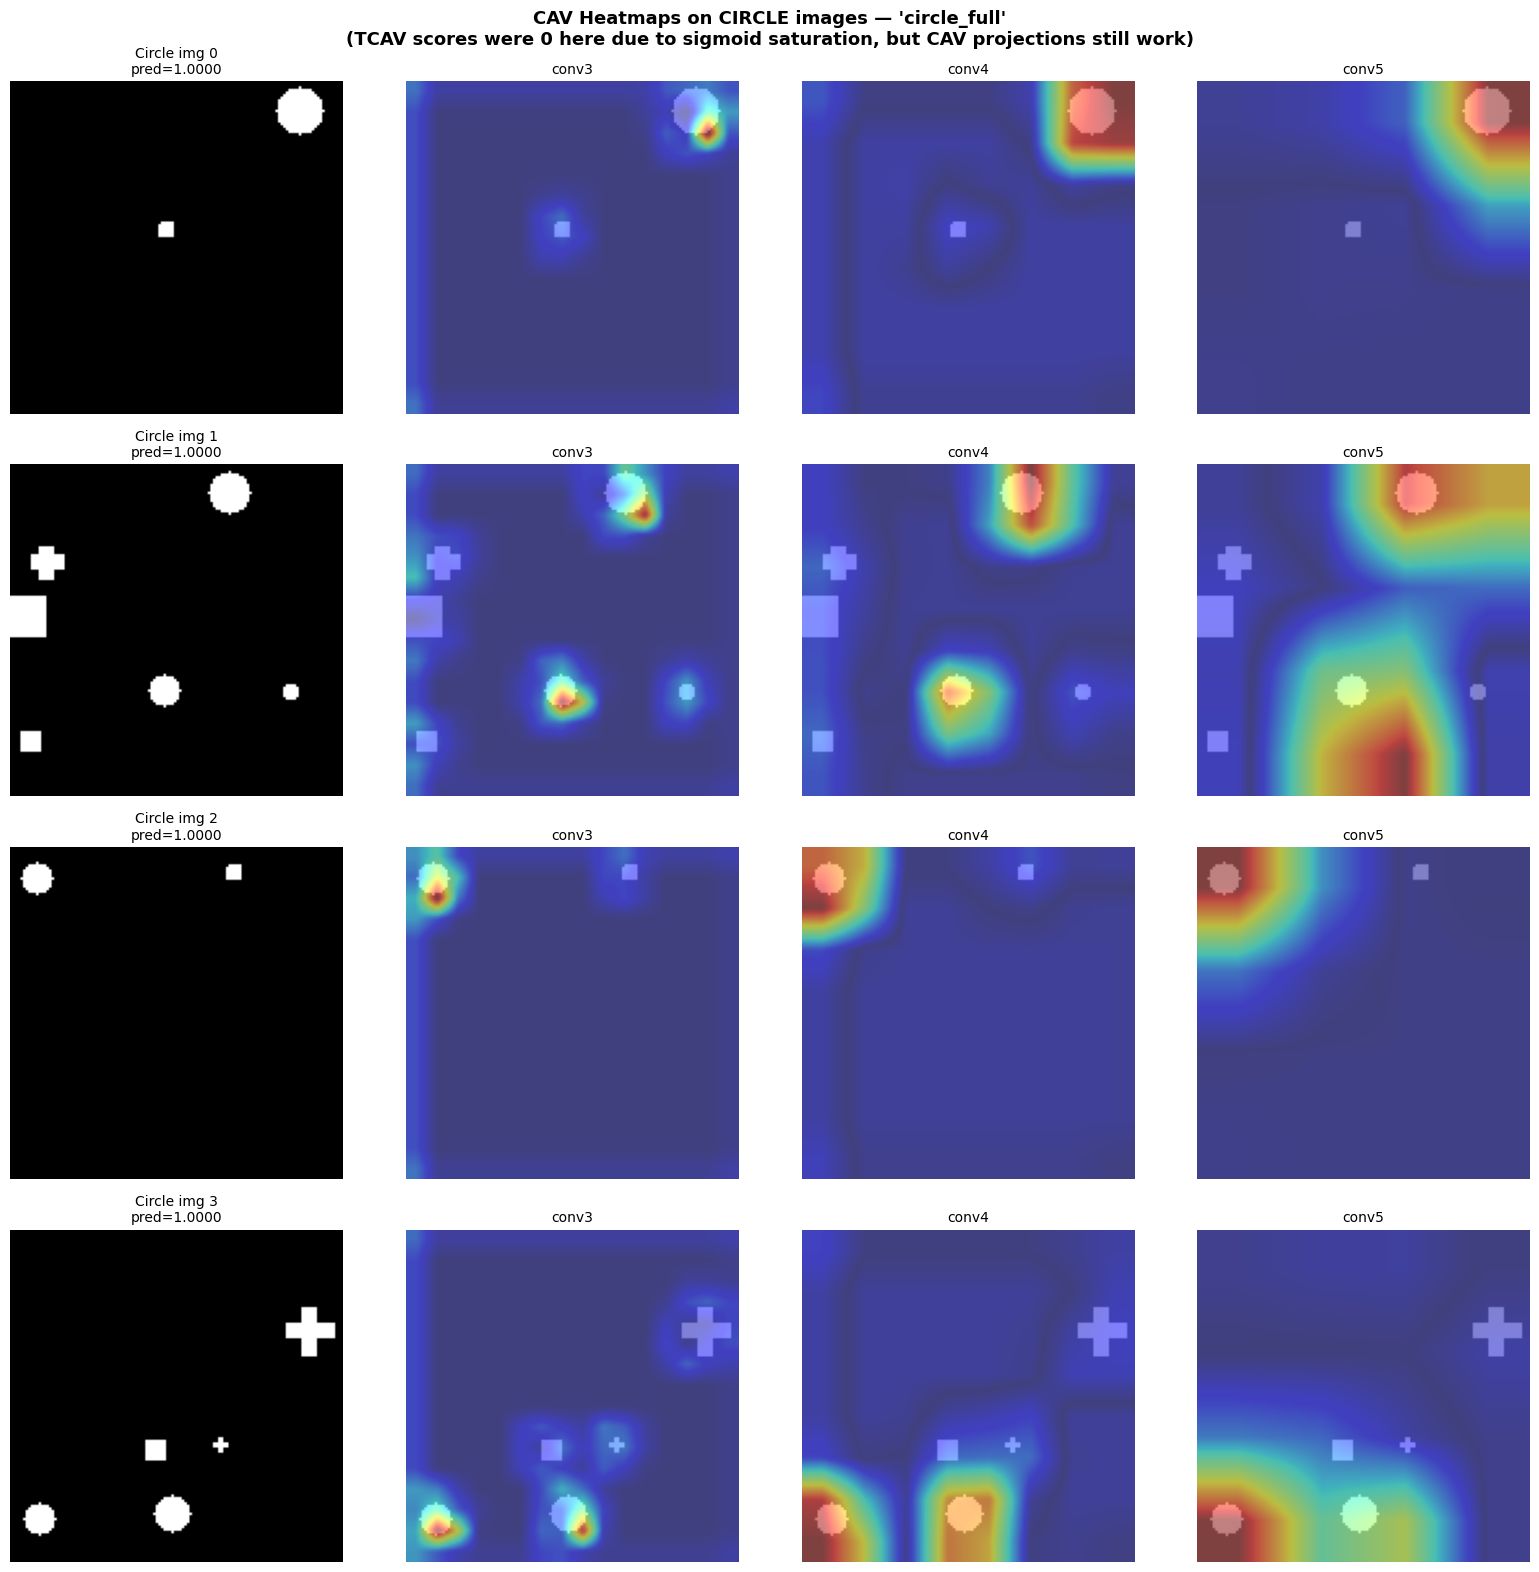

In [32]:
# ==========================================
# 17. Comparison: CAV heatmaps on CIRCLE images (where TCAV was 0)
# ==========================================
# TCAV scores were 0 for circle images due to sigmoid saturation
# (model very confident pred ≈ 1.0 → zero gradients → zero TCAV).
# But CAV spatial projections still work since they depend only on
# activations × CAV weights, not on gradients.

vis_circle = x_circle[:N_VIS]

# Forward pass
with torch.no_grad():
    vis_circle_preds = model(vis_circle).squeeze()

# Show for just one concept (circle_full) to keep it concise
concept_name = 'circle_full'
high_layers = ['conv3', 'conv4', 'conv5']

fig, axes = plt.subplots(N_VIS, len(high_layers) + 1, 
                         figsize=(4 * (len(high_layers) + 1), 4 * N_VIS))
fig.suptitle(f"CAV Heatmaps on CIRCLE images — '{concept_name}'\n"
             "(TCAV scores were 0 here due to sigmoid saturation, but CAV projections still work)", 
             fontsize=13, fontweight='bold')

for img_idx in range(N_VIS):
    ax = axes[img_idx][0]
    orig = vis_circle[img_idx, 0].cpu().numpy()
    ax.imshow(orig, cmap='gray')
    pred_val = vis_circle_preds[img_idx].item() if vis_circle_preds.dim() > 0 else vis_circle_preds.item()
    ax.set_title(f"Circle img {img_idx}\npred={pred_val:.4f}", fontsize=10)
    ax.axis('off')
    
    for col, conv_layer in enumerate(high_layers):
        mp_layer, n_channels = conv_to_maxpool[conv_layer]
        act = activations[mp_layer]
        
        w = cav_weights[concept_name][conv_layer]
        spatial_size = len(w) // n_channels
        w_reshaped = w.reshape(n_channels, spatial_size)
        channel_importance = w_reshaped.mean(axis=1)
        
        act_img = act[img_idx].cpu().numpy()
        heatmap = np.zeros(act_img.shape[1:])
        for c in range(n_channels):
            heatmap += channel_importance[c] * act_img[c]
        
        heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
        heatmap_upsampled = F.interpolate(heatmap_tensor, size=(128, 128), 
                                           mode='bilinear', align_corners=False)
        hm_abs = np.abs(heatmap_upsampled.squeeze().numpy())
        if hm_abs.max() > 0:
            hm_abs = hm_abs / hm_abs.max()
        
        ax = axes[img_idx][col + 1]
        ax.imshow(orig, cmap='gray', alpha=0.5)
        ax.imshow(hm_abs, cmap='jet', alpha=0.5, interpolation='bilinear')
        ax.set_title(f"{conv_layer}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

## Single Multi-Figure Image: MaxPool Heatmaps + Prediction

Visualize all 5 maxpool activation heatmaps for a single image that contains multiple shapes (circles, squares, crosses), along with the model's prediction and the ground truth shape counts.

Image: data/aixi_shape/val/00011.png
Ground truth: circles=0, squares=2, crosses=1
Model prediction: 0.0000
Expected label: 0.0 (sq-dominant, no circles)
Model says: sq-dominant, no circles


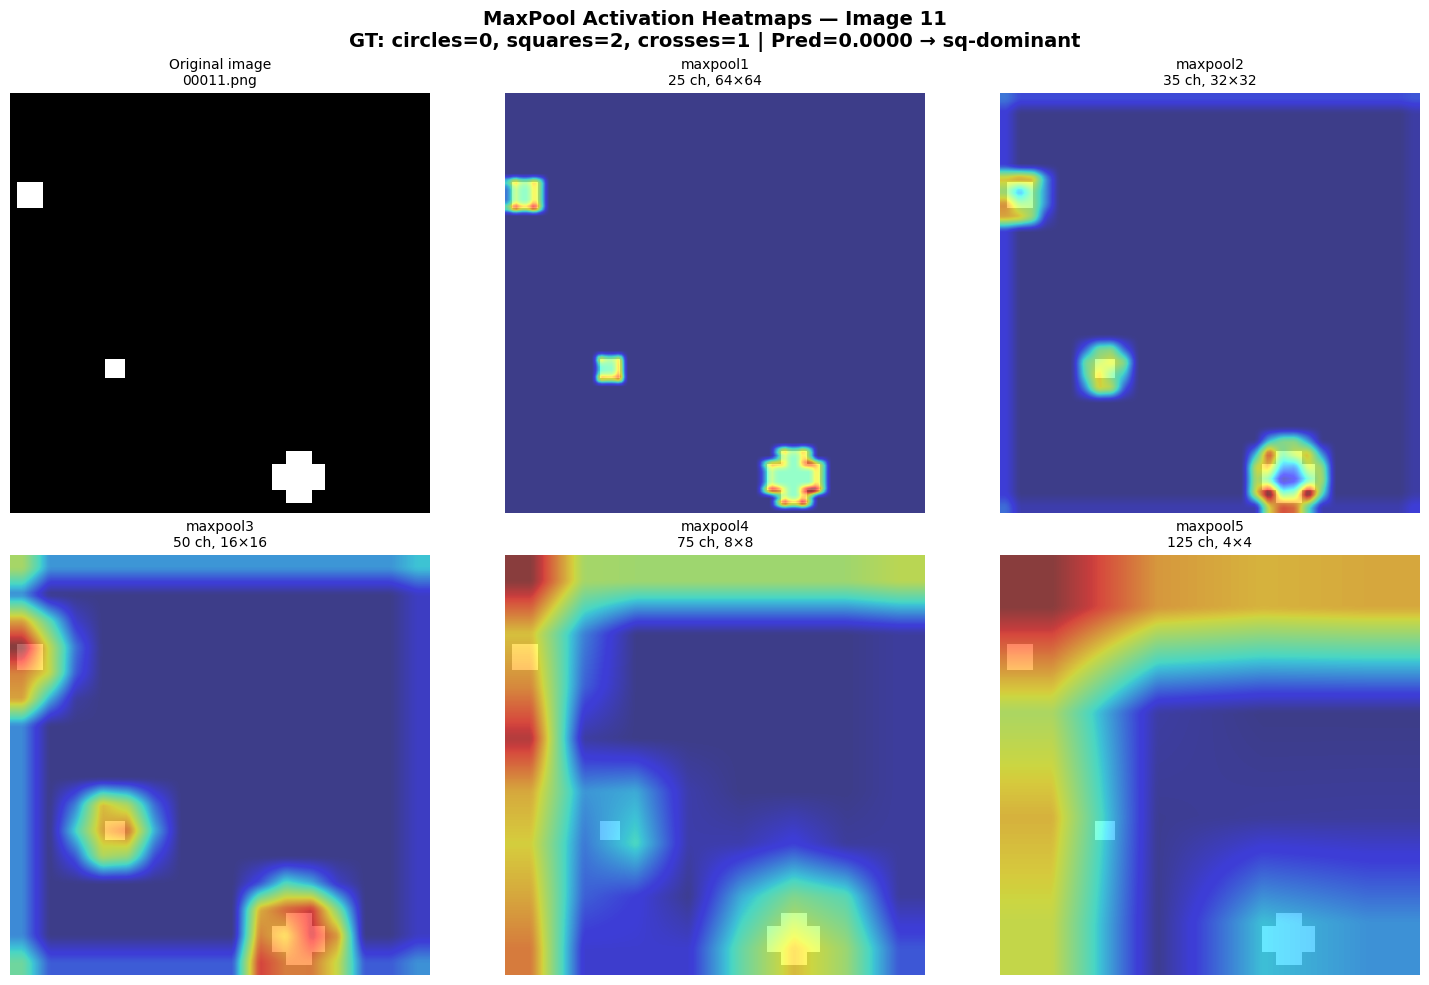

In [33]:
# ==========================================
# 18. MaxPool heatmaps for a single multi-figure image
# ==========================================
import csv as csv_mod
import torch.nn.functional as F

# Read val CSV to find a good multi-figure image
# CWD is already the project root (set by cell 1)
val_csv_path = "data/aixi_shape/val/dades.csv"
with open(val_csv_path) as f:
    reader = csv_mod.DictReader(f, delimiter=';')
    val_rows = list(reader)

# Pick image index 11: c=0, s=2, cr=1 (3 shapes, no circles → sq-dominant)
IMG_IDX = 11
row = val_rows[IMG_IDX]
n_circles, n_squares, n_crosses = int(row['c']), int(row['s']), int(row['cr'])
img_path = f"data/aixi_shape/val/{IMG_IDX:05d}.png"

print(f"Image: {img_path}")
print(f"Ground truth: circles={n_circles}, squares={n_squares}, crosses={n_crosses}")

# Load and predict
img = Image.open(img_path).convert("L")
img_tensor = transform(img).unsqueeze(0).to(DEVICE)  # [1, 1, 128, 128]

model.eval()
with torch.no_grad():
    pred = model(img_tensor).item()

# Compute expected label: label=0 iff (c==0 AND s>0 AND s>=cr)
expected_label = 0.0 if (n_circles == 0 and n_squares > 0 and n_squares >= n_crosses) else 1.0
print(f"Model prediction: {pred:.4f}")
print(f"Expected label: {expected_label} ({'has circles' if expected_label == 1.0 else 'sq-dominant, no circles'})")
print(f"Model says: {'has circles' if pred > 0.5 else 'sq-dominant, no circles'}")

# activations dict was populated by the forward pass (hooks still active)
maxpool_layers = ['maxpool1', 'maxpool2', 'maxpool3', 'maxpool4', 'maxpool5']
maxpool_info = {
    'maxpool1': (25, '64×64'),
    'maxpool2': (35, '32×32'),
    'maxpool3': (50, '16×16'),
    'maxpool4': (75, '8×8'),
    'maxpool5': (125, '4×4'),
}

# Plot: original image + 5 maxpool mean activation heatmaps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(
    f"MaxPool Activation Heatmaps — Image {IMG_IDX}\n"
    f"GT: circles={n_circles}, squares={n_squares}, crosses={n_crosses} | "
    f"Pred={pred:.4f} → {'has circles' if pred > 0.5 else 'sq-dominant'}",
    fontsize=14, fontweight='bold'
)

# Original image
ax = axes[0][0]
ax.imshow(img_tensor[0, 0].cpu().numpy(), cmap='gray')
ax.set_title(f"Original image\n{os.path.basename(img_path)}", fontsize=10)
ax.axis('off')

# 5 maxpool layers
for i, mp_name in enumerate(maxpool_layers):
    row_idx = (i + 1) // 3
    col_idx = (i + 1) % 3
    ax = axes[row_idx][col_idx]
    
    act = activations[mp_name]  # [1, C, H, W]
    n_ch, spatial = maxpool_info[mp_name]
    
    # Mean activation across channels
    mean_act = act[0].mean(dim=0).cpu().numpy()  # [H, W]
    
    # Upsample to 128x128 for overlay
    mean_tensor = torch.tensor(mean_act).unsqueeze(0).unsqueeze(0).float()
    mean_up = F.interpolate(mean_tensor, size=(128, 128), 
                            mode='bilinear', align_corners=False).squeeze().numpy()
    
    if mean_up.max() > 0:
        mean_up = mean_up / mean_up.max()
    
    ax.imshow(img_tensor[0, 0].cpu().numpy(), cmap='gray', alpha=0.4)
    ax.imshow(mean_up, cmap='jet', alpha=0.6, interpolation='bilinear')
    ax.set_title(f"{mp_name}\n{n_ch} ch, {spatial}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()